In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)


# Variability across contacts in the hole SC state

# Imports

In [7]:
file_path = '../data/raw_sweeps' # add path to data 

In [8]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
from cycler import cycler
%matplotlib inline
from matplotlib.colors import Normalize
import matplotlib.image as mpimg

from matplotlib import cm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, SymmetricalLogLocator
import matplotlib.patches as mpatches
from matplotlib.path import Path
from scipy.interpolate import splprep, splev

import sys
sys.path.append("../utils")
from utils import *

In [9]:
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 8, 
    'axes.titlesize': 8,
    'font.size': 9,
    'legend.title_fontsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5*scale,
    'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale,
    'xtick.minor.width': 1.5*scale,

    'ytick.major.size': 5*scale,
    'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale,
    'ytick.minor.width': 1.5*scale,


    # Linewidths
    'axes.linewidth': 1.5*scale,
    'lines.linewidth': 2.5*scale,
})


# Panel - fraun across 3 contacts

{'sr830_1': '29-28', 'sr830_2': '28-25', 'sr830_3': '25-24', 'sr830_4': 'I_{6-22}', 'sr830_5': '13-14', 'sr830_6': '10-11', 'sr830_7': '11-13', 'sr830_8': '11-25', 'sr830_9': '13-24'}
0.0 0.0


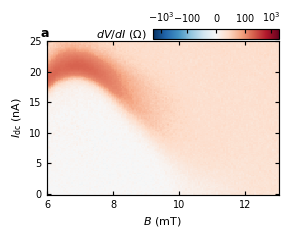

In [12]:
def plot_fraun(fig, ax, norm, cmap="viridis", contact_ind = 2, files=[1400]):
    contact_pairs = {
        'long1': {'indices': [contact_ind], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    
    gates = True
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            for file in files:
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                print(mc_0)
                md = sl.load_meta(file_path, file)
                V_bg = md['comments'][1]['V_bg']
                V_tg = md['comments'][1]['V_tg']
                n, D = calculate_n_D(V_tg, V_bg, dtg=17.25, dbg=25.5)
                xs = data['xs']
                ys = data['ys']
                phase = data[f'sr830_{ind}_P']
        
                if pair=='curr':
                    I = data['sr830_4_X']
                    zs= I/(md['comments'][1]['I_ac']*1E-9)
                else:
                    I = data['sr830_4_X']
                    Vxx = data[f'sr830_{ind}_X']
                    zs = Vxx / I
                    
                    mask = np.abs(I) < 0.0 * np.nanmax(np.abs(I))
                    zs = np.ma.array(zs, mask=mask)
 
                plot = ax.pcolormesh(ys*1e3, xs*10, zs.T, norm=norm, cmap=cmap, rasterized=True, lw=0) # factor of 10 converts to nA
            ax.set_xlabel("$B$ (mT)")
            ax.set_ylabel("$I_{\mathrm{dc}}$ (nA)")
    return plot, n, D


fig = plt.figure(figsize=(3,2))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=100, vmin=-2E3, vmax=2E3)
plot, n, D = plot_fraun(fig, ax, norm, "RdBu_r", 2, [467])
print(n, D)

fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')
cb_width = 0.42
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.05])

cb = plt.colorbar(plot, cax=cax, ticks=[-1000, -100, 0, 100, 1000], \
                  orientation='horizontal')
cb.ax.set_xticklabels([ r'$-10^3$', r'$-100$', '0', r'$100$', r'$10^3$'])
cb.ax.set_xlabel(r'$dV/dI$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')

# Full figure

{'sr830_1': '29-28', 'sr830_2': '28-25', 'sr830_3': '25-24', 'sr830_4': 'I_{6-22}', 'sr830_5': '13-14', 'sr830_6': '10-11', 'sr830_7': '11-13', 'sr830_8': '11-25', 'sr830_9': '13-24'}
(n,D) = (0.00, 0.00))
{'sr830_1': '29-28', 'sr830_2': '28-25', 'sr830_3': '25-24', 'sr830_4': 'I_{6-22}', 'sr830_5': '13-14', 'sr830_6': '10-11', 'sr830_7': '11-13', 'sr830_8': '11-25', 'sr830_9': '13-24'}
(n,D) = (0.00, 0.00))
{'sr830_1': '29-28', 'sr830_2': '28-25', 'sr830_3': '25-24', 'sr830_4': 'I_{6-22}', 'sr830_5': '13-14', 'sr830_6': '10-11', 'sr830_7': '11-13', 'sr830_8': '11-25', 'sr830_9': '13-24'}
(n,D) = (0.00, 0.00))


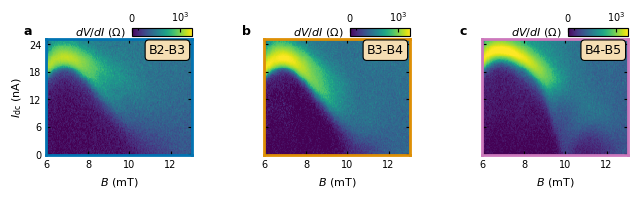

In [21]:
# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 1.5))
gs = GridSpec(1, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[1],
                       hspace=0.5, wspace=0.5)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a,b,c ##################
labels = [["a", "b", "c"]]
contact_labels = ["B2-B3", "B3-B4", "B4-B5"]
contact_colors = ["#0173B2", "#DE8F05", "#CC78BC"]
for row_ind, files in enumerate([[467]]):
    for subfig_ind, contact_ind in enumerate([1, 2, 3]):
        ax = fig.add_subplot(gs[row_ind, subfig_ind])
        norm = colors.SymLogNorm(linthresh=70, vmin=0E3, vmax=0.2E3)
        plot, n, D = plot_fraun(fig, ax, norm, "viridis", contact_ind, files)
        print("(n,D) = ({:.2f}, {:.2f}))".format(n, D))
    
        if subfig_ind in [1, 2]:
            ax.set_yticklabels([])
            ax.set_ylabel("")
        
        fig.canvas.draw()  
        pos = ax.get_position()
        label_spacer = 0.03
        fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, labels[row_ind][subfig_ind],
                 fontweight='bold')

        cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.02, cb_width, cb_height_frac])
        cb = plt.colorbar(plot, cax=cax, ticks=[-100, 0, 100], orientation='horizontal')
        cb.ax.set_xticklabels([r'$-10^3$', '0', r'$10^3$'])
        cb.ax.annotate(r'$dV/dI$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
                       ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
        cb.ax.xaxis.set_ticks_position('top')
        cb.ax.xaxis.set_label_position('top')
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor(contact_colors[subfig_ind])

        ax.text(0.96, 0.96, contact_labels[subfig_ind], transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='k',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                          edgecolor='k', linewidth=0.8, alpha=1))

plt.show()
fig.savefig("ed-fig-hole-sc-frauns.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)